In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

In [3]:
df=pd.read_excel("final_dataset.xlsx")
print(df.head())

   Column1       Branch Semester Attendance_Percentage Study_Hours_Per_Day  \
0      NaN  AIDS(cs ds)      3rd                60-70%                1 hr   
1      NaN  AIDS(cs ds)      3rd               85-100%                2 hr   
2      NaN  AIDS(cs ds)      3rd                60-70%                2 hr   
3      NaN  AIDS(cs ds)      3rd                70-85%                2 hr   
4      NaN  AIDS(cs ds)      3rd                30-60%                1 hr   

  CIE_Marks_50 Sleep_Hours Screen_Time_Hours Coding_Skill_5  \
0        45-50       6-7hr              4 hr              2   
1        45-50       6-7hr              4 hr              3   
2        30-40       6-7hr             5-7hr              3   
3        45-50       6-7hr             5-7hr              3   
4        40-45        5 hr            8-9 hr              3   

  Participates_In_Events Parental_Support_5 Motivation_5 Current_SGPA  
0              SOMETIMES                  5            5            9  
1       

In [4]:
df.drop(columns=['Column1'], inplace=True)
print(df.head())


        Branch Semester Attendance_Percentage Study_Hours_Per_Day  \
0  AIDS(cs ds)      3rd                60-70%                1 hr   
1  AIDS(cs ds)      3rd               85-100%                2 hr   
2  AIDS(cs ds)      3rd                60-70%                2 hr   
3  AIDS(cs ds)      3rd                70-85%                2 hr   
4  AIDS(cs ds)      3rd                30-60%                1 hr   

  CIE_Marks_50 Sleep_Hours Screen_Time_Hours Coding_Skill_5  \
0        45-50       6-7hr              4 hr              2   
1        45-50       6-7hr              4 hr              3   
2        30-40       6-7hr             5-7hr              3   
3        45-50       6-7hr             5-7hr              3   
4        40-45        5 hr            8-9 hr              3   

  Participates_In_Events Parental_Support_5 Motivation_5 Current_SGPA  
0              SOMETIMES                  5            5            9  
1              SOMETIMES                  5            4      

In [5]:
df.describe()


,Branch,Semester,Attendance_Percentage,Study_Hours_Per_Day,CIE_Marks_50,Sleep_Hours,Screen_Time_Hours,Coding_Skill_5,Participates_In_Events,Parental_Support_5,Motivation_5,Current_SGPA
count,122,122,122,122,122,122,122,122,122,122,122,118
unique,6,2,5,6,5,5,6,6,4,4,6,5
top,AIDS(cs ds),3rd,85-100%,3 hr,45-50,6-7hr,3 hr,4,NO,5,4,9
freq,35,121,53,37,64,73,38,40,44,60,46,68


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Branch                  122 non-null    object
 1   Semester                122 non-null    object
 2   Attendance_Percentage   122 non-null    object
 3   Study_Hours_Per_Day     122 non-null    object
 4   CIE_Marks_50            122 non-null    object
 5   Sleep_Hours             122 non-null    object
 6   Screen_Time_Hours       122 non-null    object
 7   Coding_Skill_5          122 non-null    object
 8   Participates_In_Events  122 non-null    object
 9   Parental_Support_5      122 non-null    object
 10  Motivation_5            122 non-null    object
 11  Current_SGPA            118 non-null    object
dtypes: object(12)
memory usage: 11.6+ KB


In [7]:
df.isnull().sum()

Branch                    0
Semester                  0
Attendance_Percentage     0
Study_Hours_Per_Day       0
CIE_Marks_50              0
Sleep_Hours               0
Screen_Time_Hours         0
Coding_Skill_5            0
Participates_In_Events    0
Parental_Support_5        0
Motivation_5              0
Current_SGPA              4
dtype: int64

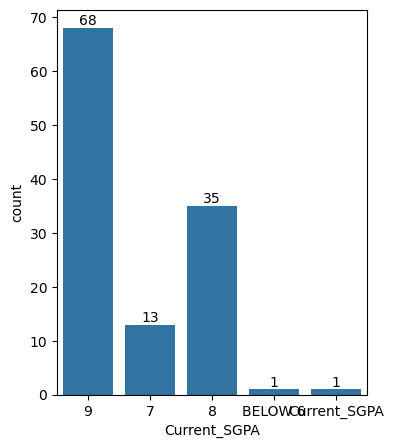

In [8]:
plt.figure(figsize=(4,5))
var=sns.countplot(data=df, x="Current_SGPA")
var.bar_label(var.containers[0])
plt.show()

#9 scgpas is the highest among all

In [10]:
cols = ["CIE_Marks_50", "Study_Hours_Per_Day", "Coding_Skill_5", "Motivation_5"]

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')


#Here initially before pd.to_numeric, errors='coerce' it was throwing an error but by using this function coerce we can avoid error as abc ,empty spaces or anyother mixed datatypes are converted as NAN.

In [11]:
gb=df.groupby("Parental_Support_5").agg({"CIE_Marks_50":'mean',"Study_Hours_Per_Day":'mean',"Coding_Skill_5":'mean',"Motivation_5":'mean'})
print(gb)


                    CIE_Marks_50  Study_Hours_Per_Day  Coding_Skill_5  \
Parental_Support_5                                                      
3                            NaN                  NaN        3.705882   
4                            NaN                  NaN        3.568182   
5                            NaN                  NaN        3.416667   
Parental_Support_5           NaN                  NaN             NaN   

                    Motivation_5  
Parental_Support_5                
3                       4.058824  
4                       4.068182  
5                       3.716667  
Parental_Support_5           NaN  


# parental support 3 affecting cie marks in average i.e mean is calculated in the first step

#SInce my columns contain NAN so I must convert my NAN into  numeric only values.For cie marks we can remove hyphon and calculate the midpoints of the range

In [41]:
# ==========================
def to_num(val):
    if pd.isna(val):
        return np.nan
    
    s = str(val).lower().strip()

    # Remove quotes
    s = s.replace("'", "").replace('"', "")

    # Normalize all types of dashes
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")

    # Remove unwanted words
    s = s.replace("hr", "").replace("hrs", "").replace("hours", "")
    s = s.replace("to", "-")
    s = s.replace("%", "")
    s = s.replace(",", "")

    # Extract all numbers
    nums = re.findall(r"\d+(?:\.\d+)?", s)

    # Range → midpoint
    if len(nums) >= 2:
        return (float(nums[0]) + float(nums[1])) / 2
    
    # Single number
    if len(nums) == 1:
        return float(nums[0])
    
    return np.nan

# ==========================
# 3. Apply to mixed columns
# ==========================
mixed_cols = [
    "Attendance_Percentage",
    "Study_Hours_Per_Day",
    "CIE_Marks_50",
    "Sleep_Hours",
    "Screen_Time_Hours"
]

for col in mixed_cols:
    if col in df.columns:
        df[col] = df[col].apply(to_num)

# ==========================
# 4. Convert YES/NO/SOMETIMES etc.
# ==========================
event_map = {
    "yes": 1,
    "no": 0,
    "sometimes": 0.5,
    "rarely": 0.25,
    "often": 1
}

if "Participates_In_Events" in df.columns:
    df["Participates_In_Events"] = (
        df["Participates_In_Events"]
        .astype(str)
        .str.lower()
        .map(event_map)
    )

# ==========================
# 5. Force numeric for these
# ==========================
num_cols = ["Coding_Skill_5", "Parental_Support_5", "Motivation_5", "Current_SGPA"]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ==========================
# 6. Encode any leftover object columns
# ==========================
for col in df.select_dtypes(include="object").columns:
    df[col + "_cat"] = df[col].astype("category").cat.codes.replace({-1: np.nan})

# ==========================
# 7. Save cleaned dataset
# ==========================
df.to_excel("cleaned_output.xlsx", index=False)

print("Cleaning complete! Saved as cleaned_output.xlsx")

Cleaning complete! Saved as cleaned_output.xlsx


In [43]:
df = pd.read_excel("final_dataset_CLEANED_FULL.xlsx")
df.head()



,Column1,Branch,Semester,Attendance_Percentage,Study_Hours_Per_Day,CIE_Marks_50,Sleep_Hours,Screen_Time_Hours,Coding_Skill_5,Participates_In_Events,Parental_Support_5,Motivation_5,Current_SGPA,Branch_cat,Semester_cat
0,NaN,AIDS(cs ds),3rd,65.0,1.0,47.5,6.5,4.0,2.0,0.5,5.0,5.0,9.0,0,0
1,NaN,AIDS(cs ds),3rd,92.5,2.0,47.5,6.5,4.0,3.0,0.5,5.0,4.0,9.0,0,0
2,NaN,AIDS(cs ds),3rd,65.0,2.0,35.0,6.5,6.0,3.0,0.5,5.0,4.0,7.0,0,0
3,NaN,AIDS(cs ds),3rd,77.5,2.0,47.5,6.5,6.0,3.0,0.0,5.0,1.0,9.0,0,0
4,NaN,AIDS(cs ds),3rd,45.0,1.0,42.5,5.0,8.5,3.0,0.0,5.0,2.0,9.0,0,0


In [ ]:
df = df.drop(index=22)
df = df.reset_index(drop=True)


In [ ]:
df.to_excel("cleaned_output.xlsx", index=False)


In [ ]:
# Remove the bad row where Branch == "Branch" or Semester == "Semester"
df = df[~((df["Branch"] == "Branch") & (df["Semester"] == "Semester"))]

# Reset the index
df = df.reset_index(drop=True)

# Save updated file
df.to_excel("final_dataset_CLEANED_FULL_no_badrow.xlsx", index=False)

print("Removed the unwanted row successfully!")


Removed the unwanted row successfully!


In [ ]:
df = pd.read_excel("final_dataset_CLEANED_FULL_no_badrow.xlsx")
df.head()


,Column1,Branch,Semester,Attendance_Percentage,Study_Hours_Per_Day,CIE_Marks_50,Sleep_Hours,Screen_Time_Hours,Coding_Skill_5,Participates_In_Events,Parental_Support_5,Motivation_5,Current_SGPA,Branch_cat,Semester_cat
0,NaN,AIDS(cs ds),3rd,65.0,1,47.5,6.5,4.0,2,0.5,5,5,9.0,0,0
1,NaN,AIDS(cs ds),3rd,92.5,2,47.5,6.5,4.0,3,0.5,5,4,9.0,0,0
2,NaN,AIDS(cs ds),3rd,65.0,2,35.0,6.5,6.0,3,0.5,5,4,7.0,0,0
3,NaN,AIDS(cs ds),3rd,77.5,2,47.5,6.5,6.0,3,0.0,5,1,9.0,0,0
4,NaN,AIDS(cs ds),3rd,45.0,1,42.5,5.0,8.5,3,0.0,5,2,9.0,0,0
